# Part 1: Acne Detection on ACNE04

This notebook trains and compares **three object detectors** on the ACNE04 dataset:

| Model | Family | Anchors |
|---|---|---|
| **YOLOv8** | One-stage CNN | Anchor-free |
| **Faster R-CNN + ResNet50-FPN** | Two-stage CNN | Anchor-based |
| **RT-DETR** (DINO family) | One-stage Transformer | Anchor-free queries |

Run end-to-end on Colab (T4 GPU) in ~3 hours.


## 0. Setup

Link: https://github.com/nprakash1/acne_yang_project/tree/main/part1_detection

In [1]:
# Auto-detect how the project got into this Colab runtime.
# Supports three workflows -- you don't have to edit anything:
#   (1) git clone   - set GITHUB_URL below to a public repo URL
#   (2) zip upload  - drag acne_yang_project.zip into Colab's file pane
#   (3) Drive copy  - put the unzipped folder anywhere in your Drive
import os, glob, subprocess

GITHUB_URL = 'https://github.com/nprakash1/acne_yang_project.git'
PROJECT_DIR = 'acne_yang_project'

def _is_project_root(p):
    return os.path.isdir(os.path.join(p, 'part1_detection')) and \
           os.path.isfile(os.path.join(p, 'requirements.txt'))

# Already at project root?
if _is_project_root('.'):
    print('[setup] already at project root')
elif os.path.isdir(PROJECT_DIR) and _is_project_root(PROJECT_DIR):
    %cd $PROJECT_DIR
    print(f'[setup] cd into ./{PROJECT_DIR}')
else:
    zips = glob.glob('/content/*.zip') + glob.glob('./*.zip')
    drive_hits = glob.glob('/content/drive/MyDrive/**/part1_detection', recursive=True)
    if zips:
        z = zips[0]
        print(f'[setup] unzipping {z}')
        subprocess.check_call(['unzip', '-q', '-o', z, '-d', '/content/_extracted'])
        roots = [r for r, _, _ in os.walk('/content/_extracted') if _is_project_root(r)]
        assert roots, 'zip did not contain a project root (part1_detection/ + requirements.txt)'
        %cd $roots[0]
    elif drive_hits:
        root = os.path.dirname(drive_hits[0])
        print(f'[setup] using project from Drive: {root}')
        %cd $root
    elif GITHUB_URL:
        print(f'[setup] cloning {GITHUB_URL}')
        subprocess.check_call(['git', 'clone', GITHUB_URL])
        %cd $PROJECT_DIR
    else:
        raise RuntimeError(
            'No project source found. Either:\n'
            ' - set GITHUB_URL above to your repo, or\n'
            ' - drag acne_yang_project.zip into the Colab file pane and re-run, or\n'
            ' - mount Drive (next cell) with the project folder inside MyDrive.'
        )

print('[setup] cwd =', os.getcwd())
!pip install -q -r requirements.txt
print('[setup] dependencies installed')

[setup] cloning https://github.com/nprakash1/acne_yang_project.git
/content/acne_yang_project
[setup] cwd = /content/acne_yang_project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 81.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 125.6 MB/s eta 0:00:00
[setup] dependencies installed


In [2]:

# Mount drive (optional, for persisting weights)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

Mounted at /content/drive


## 1. Download ACNE04

We pull the dataset from Roboflow Universe in **both YOLOv8 and COCO formats** so the same images back all three models. You need a free Roboflow API key from https://app.roboflow.com/settings/api.

In [3]:
import os
os.environ['ROBOFLOW_API_KEY'] = 'c1orEQIdQdZYPwUiFe2I'

from part1_detection.data import download_acne04, build_yaml
yolo_root = download_acne04(out_dir='data/acne04', fmt='yolov8')
coco_root = download_acne04(out_dir='data/acne04', fmt='coco')
yaml_path = build_yaml(yolo_root, 'data/acne04.yaml')
print('YOLO root:', yolo_root)
print('COCO root:', coco_root)
print('YAML:', yaml_path)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/acne_yang_project/data/acne04/yolov8 in yolov8:: 100%|██████████| 6808/6808 [00:00<00:00, 8996.50it/s]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/acne_yang_project/data/acne04/coco in coco:: 100%|██████████| 3406/3406 [00:00<00:00, 6974.48it/s]


YOLO root: /content/acne_yang_project/data/acne04/yolov8
COCO root: /content/acne_yang_project/data/acne04/coco
YAML: /content/acne_yang_project/data/acne04.yaml


### Fix YOLO class labels (critical)

Roboflow's ACNE04 YOLO export uses class ids `0/1/2/3` for the four severity levels (`levle0..levle3`), but our pipeline treats acne as a **single class**. Ultralytics silently drops every label whose class id exceeds `nc-1`, so without this remap ~75% of training data is thrown away as 'corrupt'. Safe to re-run.

In [4]:
from part1_detection.fix_yolo_labels import remap_labels_to_single_class
remap_labels_to_single_class(str(yolo_root))


[fix_yolo_labels] root           : /content/acne_yang_project/data/acne04/yolov8
[fix_yolo_labels] label files    : 3398
[fix_yolo_labels] files changed  : 3051
[fix_yolo_labels] lines remapped : 25925
[fix_yolo_labels] caches removed : 0


{'files_total': 3398,
 'files_changed': 3051,
 'lines_changed': 25925,
 'labels_cache_removed': 0}

## 1.75 (Optional) Resume from Drive

If you lost the previous Colab session but already ran the training cells **and** the `Save to Drive` cell at the bottom, you can skip training and go straight to evaluation / visualization. This cell:

1. Mirrors `outputs/` and `runs/` from `MyDrive/acne_yang_project_runs/` back onto the Colab local disk so the hard-coded weight paths in cell 20 and cell 22 just work.
2. Auto-skips if there's nothing in Drive yet (first run).

**Skip this cell if you intend to re-train from scratch.**

In [ ]:
# === RESUME FROM DRIVE ===
import os, shutil
from pathlib import Path

DRIVE_ROOT = '/content/drive/MyDrive/acne_yang_project_runs'

if not os.path.isdir(DRIVE_ROOT):
    print(f'[resume] {DRIVE_ROOT} not found -- nothing to restore. '
          'Mount Drive first (cell above) or skip this cell on first run.')
else:
    for sub in ('outputs', 'runs'):
        src = os.path.join(DRIVE_ROOT, sub)
        if os.path.isdir(src):
            print(f'[resume] copying {src} -> ./{sub}')
            shutil.copytree(src, sub, dirs_exist_ok=True)
        else:
            print(f'[resume] {src} not found -- skipping')

    # Sanity-print which weight files we ended up with so cell 20 doesn't
    # silently fail with FileNotFoundError later.
    expected = [
        'runs/detect/outputs/yolov8/acne/weights/best.pt',
        'runs/detect/outputs/rtdetr/acne/weights/best.pt',
        'outputs/faster_rcnn/best.pth',
        # Some users save Ultralytics runs directly under outputs/ -- check both.
        'outputs/yolov8/acne/weights/best.pt',
        'outputs/rtdetr/acne/weights/best.pt',
    ]
    print('\n[resume] weight files found:')
    for p in expected:
        mark = 'OK ' if Path(p).is_file() else '-- '
        size = f' ({Path(p).stat().st_size / 1e6:.1f} MB)' if Path(p).is_file() else ''
        print(f'  {mark}{p}{size}')


[resume] copying /content/drive/MyDrive/acne_yang_project_runs/outputs -> ./outputs
[resume] copying /content/drive/MyDrive/acne_yang_project_runs/runs -> ./runs

[resume] weight files found:
  OK runs/detect/outputs/yolov8/acne/weights/best.pt (52.0 MB)
  OK runs/detect/outputs/rtdetr/acne/weights/best.pt (66.2 MB)
  OK outputs/faster_rcnn/best.pth (165.7 MB)
  -- outputs/yolov8/acne/weights/best.pt
  -- outputs/rtdetr/acne/weights/best.pt


In [ ]:
!ls -lh outputs/yolov8/acne/weights/best.pt runs/detect/outputs/yolov8/acne/weights/best.pt 2>/dev/null

-rw------- 1 root root 50M May 14 11:03 runs/detect/outputs/yolov8/acne/weights/best.pt


## 1.5 Inspect GT bounding boxes

ACNE04 lesions are *small* (typically 5-30 px). Before training we measure the actual size distribution to:

1. **Sanity-check** the dataset annotations.
2. Choose **data-driven anchor sizes** for Faster R-CNN (torchvision defaults target COCO objects, ~10x larger).
3. Confirm an `imgsz` for YOLO / RT-DETR that makes the median lesion comfortably visible to the FPN.

Outputs land in `outputs/eda/`.

Loaded 39,714 annotations across 2,973 images from /content/acne_yang_project/data/acne04/coco/train/_annotations.coco.json
Wrote outputs/eda/gt_size_stats.json
Wrote outputs/eda/gt_size_distribution.png + 2 more

=== Summary ===
  Images       : 2,973
  Boxes        : 39,714
  Median image : [640.0, 640.0]

  Box size (px, sqrt(w*h)):
      p1:   13.1
      p5:   18.3
     p25:   25.2
     p50:   31.0
     p75:   37.8
     p95:   50.9
     p99:   63.0

  Aspect ratio (w/h):
      p5:   0.57
     p25:   0.83
     p50:   1.05
     p75:   1.30
     p95:   1.80

  Boxes per image:
      p5:    1.0
     p50:    7.0
     p95:   57.0
    max : 65

=== Detector tuning recommendations ===

Faster R-CNN anchor_sizes (data-driven):
    ((14, 22), (20, 31), (25, 39), (30, 48), (41, 64))
  Compare to current code:
    ((4, 6), (8, 12), (16, 24), (32, 48), (64, 96))

Faster R-CNN aspect_ratios (data-driven):
    (0.83, 1.05, 1.3)
  Compare to current code:
    (0.5, 1.0, 2.0)

box_detections_per_im

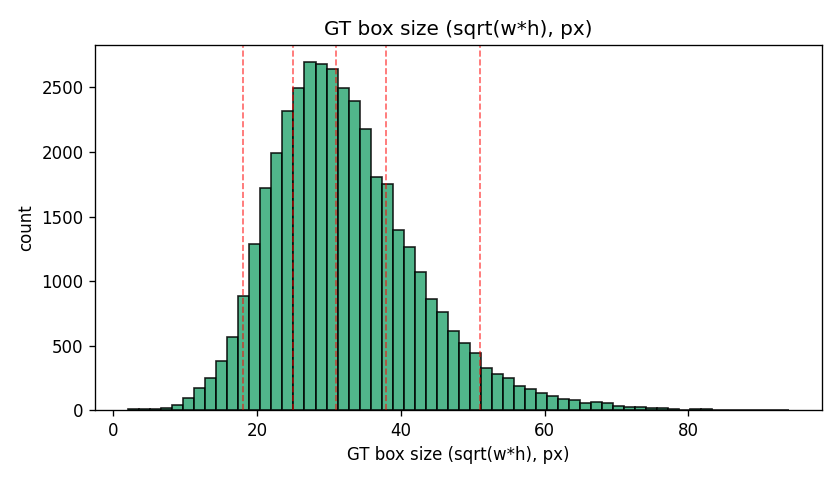

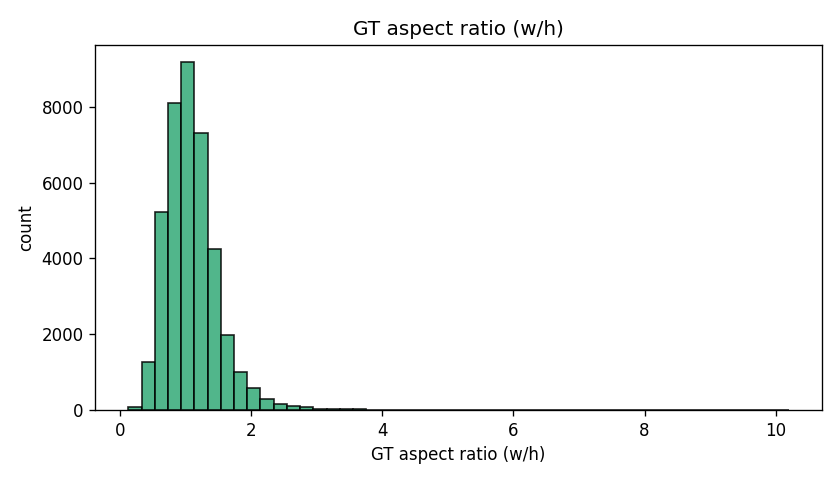

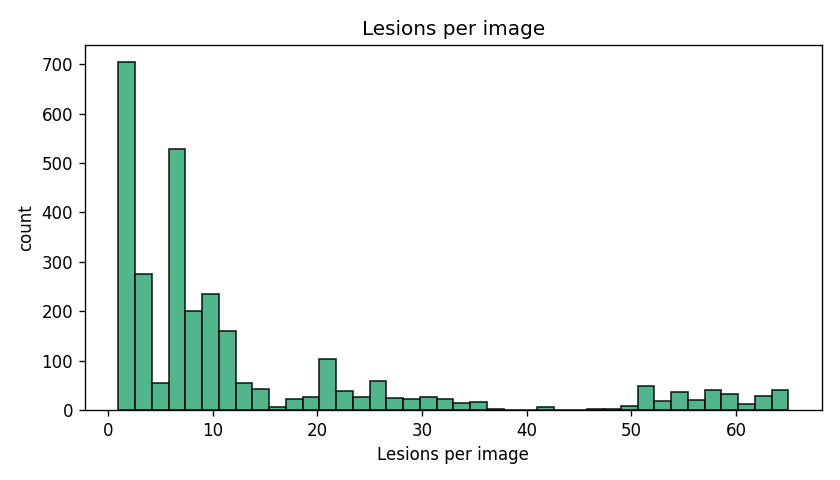

In [5]:
from part1_detection.analyze_gt import analyze
from IPython.display import Image as IPyImage, display

gt_stats = analyze(
    coco_path=f'{coco_root}/train/_annotations.coco.json',
    out_dir='outputs/eda',
)

for fn in ('gt_size_distribution.png',
           'gt_aspect_distribution.png',
           'gt_per_image.png'):
    display(IPyImage(filename=f'outputs/eda/{fn}'))


### Apply data-driven settings to the detectors

The cell below reads `gt_stats` and:

* Builds `REC_ANCHOR_SIZES` / `REC_ASPECT_RATIOS` for Faster R-CNN.
* Picks `IMGSZ` so the **median lesion is ~16 px after resize** (FPN P3 stride-8 -- the sweet spot for small-object recall). Rounded to a multiple of 32 and clipped to [640, 1536].
* Monkey-patches `train_faster_rcnn.build_model` so the training cell below picks up the new anchors with no code edit.

In [6]:
# Data-driven anchor sizes for Faster R-CNN ----------------------
REC_ANCHOR_SIZES  = tuple(tuple(t) for t in gt_stats['recommended_anchor_sizes'])
REC_ASPECT_RATIOS = tuple(gt_stats['recommended_aspect_ratios'])
print('anchor_sizes  :', REC_ANCHOR_SIZES)
print('aspect_ratios :', REC_ASPECT_RATIOS)

# Data-driven imgsz for YOLO / RT-DETR ---------------------------
med_lesion = gt_stats['box_size_px']['p50']
src_w      = gt_stats['image_size_median'][0]
raw_imgsz  = src_w * 16.0 / max(med_lesion, 1.0)
IMGSZ      = int(min(1536, max(640, round(raw_imgsz / 32) * 32)))
print(f'median lesion={med_lesion:.1f} px in {src_w:.0f}-px image '
      f'-> imgsz={IMGSZ}')

# Patch build_model() to use data-driven anchors. IDEMPOTENT: stash
# the true original on the module the first time so re-running this
# cell doesn't capture the already-patched version (infinite recursion).
import part1_detection.train_faster_rcnn as _frcnn_mod
from torchvision.models.detection.rpn import AnchorGenerator, RPNHead

if not hasattr(_frcnn_mod, '_orig_build_model'):
    _frcnn_mod._orig_build_model = _frcnn_mod.build_model

def _build_data_driven(num_classes=2, small_anchors=True):
    model = _frcnn_mod._orig_build_model(
        num_classes=num_classes, small_anchors=False,
    )
    model.rpn.anchor_generator = AnchorGenerator(
        sizes=REC_ANCHOR_SIZES,
        aspect_ratios=(REC_ASPECT_RATIOS,) * len(REC_ANCHOR_SIZES),
    )
    in_ch  = model.backbone.out_channels
    n_anch = model.rpn.anchor_generator.num_anchors_per_location()[0]
    model.rpn.head = RPNHead(in_ch, n_anch)
    return model

_frcnn_mod.build_model = _build_data_driven
print('[patched] train_faster_rcnn.build_model -> data-driven anchors '
      '(idempotent)')


anchor_sizes  : ((14, 22), (20, 31), (25, 39), (30, 48), (41, 64))
aspect_ratios : (0.83, 1.05, 1.3)
median lesion=31.0 px in 640-px image -> imgsz=640
[patched] train_faster_rcnn.build_model -> data-driven anchors (idempotent)


## 2. Train YOLOv8

In [7]:
from part1_detection.train_ultralytics import train_yolo
# Use the data-driven imgsz so the median lesion is ~16 px to the model.
# Batch is left to the per-model default (8 for yolov8m) so it fits on T4.
yolo_results = train_yolo(
    data=str(yaml_path), epochs=150, imgsz=IMGSZ,
)


Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/acne_yang_project/data/acne04.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=acne, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

## 3. Train Faster R-CNN (ResNet50-FPN)

In [8]:
from part1_detection.train_faster_rcnn import train as train_frcnn
# longer schedule + smaller LR to match the bigger min/max image size and tighter anchors
frcnn_model = train_frcnn(coco_root=str(coco_root), epochs=40, batch_size=2, lr=2e-3)

train images: 2973  |  val images: 283
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 222MB/s]


  epoch 1 step 0/1487 loss 1.3362 (1.3362 avg)
  epoch 1 step 20/1487 loss 0.6656 (0.8459 avg)
  epoch 1 step 40/1487 loss 0.4312 (0.6340 avg)
  epoch 1 step 60/1487 loss 0.6241 (0.5916 avg)
  epoch 1 step 80/1487 loss 0.3811 (0.5890 avg)
  epoch 1 step 100/1487 loss 0.6669 (0.6026 avg)
  epoch 1 step 120/1487 loss 1.3952 (0.6295 avg)
  epoch 1 step 140/1487 loss 1.1107 (0.6288 avg)
  epoch 1 step 160/1487 loss 0.4234 (0.6377 avg)
  epoch 1 step 180/1487 loss 0.2981 (0.6336 avg)
  epoch 1 step 200/1487 loss 0.6183 (0.6297 avg)
  epoch 1 step 220/1487 loss 0.5065 (0.6348 avg)
  epoch 1 step 240/1487 loss 0.6846 (0.6348 avg)
  epoch 1 step 260/1487 loss 0.7192 (0.6263 avg)
  epoch 1 step 280/1487 loss 0.3745 (0.6298 avg)
  epoch 1 step 300/1487 loss 0.4445 (0.6224 avg)
  epoch 1 step 320/1487 loss 0.5025 (0.6234 avg)
  epoch 1 step 340/1487 loss 0.0654 (0.6190 avg)
  epoch 1 step 360/1487 loss 0.6523 (0.6220 avg)
  epoch 1 step 380/1487 loss 0.8736 (0.6311 avg)
  epoch 1 step 400/1487 lo

## 4. Train RT-DETR (DINO family)

In [9]:
from part1_detection.train_ultralytics import train_rtdetr
# RT-DETR benefits equally from the larger, data-driven input.
rtdetr_results = train_rtdetr(
    data=str(yaml_path), epochs=120, imgsz=IMGSZ, batch=6,
)


Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/acne_yang_project/data/acne04.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=acne, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      1/120      5.88G       1.11     0.5874     0.2404          3        640: 100% ━━━━━━━━━━━━ 496/496 2.8it/s 2:55
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 3.8it/s 6.2s
                   all        283       3425      0.409      0.404      0.295     0.0665

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/120      6.17G      1.019     0.4636      0.151          6        640: 0% ──────────── 0/496  0.3s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      2/120      6.17G     0.9712      0.498     0.1767          3        640: 100% ━━━━━━━━━━━━ 496/496 3.2it/s 2:36
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 10.4it/s 2.3s
                   all        283       3425      0.367      0.385      0.271     0.0604

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      3/120      6.17G     0.9841     0.5047     0.2299          6        640: 0% ──────────── 0/496  0.3s

...

     58/120      6.18G     0.8311     0.4803     0.1428          3        640: 100% ━━━━━━━━━━━━ 496/496 3.1it/s 2:40
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 10.2it/s 2.4s
                   all        283       3425      0.432       0.42       0.31     0.0692

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     59/120      6.18G     0.9463     0.4212     0.2001          6        640: 0% ──────────── 0/496  0.4s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


     59/120      6.18G     0.8202     0.4791     0.1384          3        640: 100% ━━━━━━━━━━━━ 496/496 3.1it/s 2:40
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 10.0it/s 2.4s
                   all        283       3425      0.423      0.445      0.314       0.07

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     60/120      6.18G     0.8638     0.4408     0.1671          6        640: 0% ──────────── 0/496  0.3s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


     60/120      6.18G     0.8325     0.4792     0.1407          3        640: 100% ━━━━━━━━━━━━ 496/496 3.1it/s 2:40
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 10.0it/s 2.4s
                   all        283       3425      0.427      0.401      0.299     0.0674
EarlyStopping: Training stopped early as no improvement observed in last 30 epochs. Best results observed at epoch 30, best model saved as best.pt.
To update EarlyStopping(patience=30) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

60 epochs completed in 2.712 hours.
Optimizer stripped from /content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/last.pt, 66.2MB
Optimizer stripped from /content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/best.pt, 66.2MB

Validating /content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/best.pt...
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10

## 5. Unified Evaluation (mAP / P / R / IoU)

All three models scored with the **same pycocotools COCOeval** for an apples-to-apples comparison.

In [10]:
# Auto-discover weight files. Pools matches from ALL globs and
# returns the globally most-recent file, so a stale weight that
# happened to be restored into the first-tried directory doesn't
# shadow a freshly-trained one written to a different directory.
import glob, os

def _find_best(globs, label=''):
    pool = []
    for g in globs:
        pool.extend(glob.glob(g, recursive=True))
    pool = sorted(set(pool), key=lambda p: -os.path.getmtime(p))
    if not pool:
        raise FileNotFoundError(f'{label}: no match in {globs}')
    if len(pool) > 1:
        print(f'[{label}] {len(pool)} candidates found, picking newest:')
        for p in pool[:5]:
            from datetime import datetime
            mt = datetime.fromtimestamp(os.path.getmtime(p)).strftime('%Y-%m-%d %H:%M')
            sz = os.path.getsize(p) / 1e6
            print(f'   {mt}  {sz:6.1f} MB  {p}')
    return pool[0]

YOLO_WEIGHTS  = _find_best([
    'runs/detect/outputs/yolov8/**/weights/best.pt',
    'outputs/yolov8/**/weights/best.pt',
    '/content/**/yolov8/**/weights/best.pt',
], 'YOLO')
RTDETR_WEIGHTS = _find_best([
    'runs/detect/outputs/rtdetr/**/weights/best.pt',
    'outputs/rtdetr/**/weights/best.pt',
    '/content/**/rtdetr/**/weights/best.pt',
], 'RTDETR')
FRCNN_WEIGHTS  = _find_best([
    'outputs/faster_rcnn/best.pth',
    'outputs/faster_rcnn/**/best.pth',
], 'FRCNN')
print('\nUSING:')
print('  YOLO  :', YOLO_WEIGHTS)
print('  FRCNN :', FRCNN_WEIGHTS)
print('  RTDETR:', RTDETR_WEIGHTS)

# Force Python to drop cached modules so a fresh evaluate.py is used
# (Colab's `!git pull` updates files on disk but not sys.modules).
import importlib, sys
for mod in list(sys.modules):
    if mod.startswith('part1_detection'):
        del sys.modules[mod]

from part1_detection.evaluate import evaluate_model
import pandas as pd

metrics = {}
metrics['YOLOv8']       = evaluate_model('yolo',   YOLO_WEIGHTS,   str(coco_root))
metrics['Faster R-CNN'] = evaluate_model('frcnn',  FRCNN_WEIGHTS,  str(coco_root))
metrics['RT-DETR']      = evaluate_model('rtdetr', RTDETR_WEIGHTS, str(coco_root))

df = pd.DataFrame(metrics).T[
    ['mAP@0.5', 'mAP@0.5:0.95', 'precision@0.5', 'recall@0.5', 'mean_iou', 'score_thr', 'f1']
]
df


[YOLO] 8 candidates found, picking newest:
   2026-05-23 22:40    52.0 MB  /content/acne_yang_project/runs/detect/outputs/yolov8/acne/weights/best.pt
   2026-05-23 22:40    52.0 MB  runs/detect/outputs/yolov8/acne/weights/best.pt
   2026-05-14 11:03    52.0 MB  /content/drive/MyDrive/acne_yang_project_runs/runs/detect/outputs/yolov8/acne/weights/best.pt
   2026-05-14 11:02    52.0 MB  /content/drive/MyDrive/acne_yang_project_runs/snap_20260514_1103/runs/detect/outputs/yolov8/acne/weights/best.pt
   2026-05-13 22:42    22.5 MB  /content/drive/MyDrive/acne_yang_project_runs/snap_20260514_0220/runs/detect/outputs/yolov8/acne/weights/best.pt
[RTDETR] 8 candidates found, picking newest:
   2026-05-24 03:23    66.2 MB  /content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/best.pt
   2026-05-24 03:23    66.2 MB  runs/detect/outputs/rtdetr/acne/weights/best.pt
   2026-05-14 02:21    66.2 MB  /content/drive/MyDrive/acne_yang_project_runs/runs/detect/outputs/rtdetr/acne/weights/best

,mAP@0.5,mAP@0.5:0.95,precision@0.5,recall@0.5,mean_iou,score_thr,f1
YOLOv8,0.279115,0.069389,0.394261,0.363846,0.629940,0.15,0.378443
Faster R-CNN,0.125229,0.026564,0.283113,0.196891,0.622124,0.80,0.232258
RT-DETR,0.325330,0.081011,0.439930,0.436385,0.636608,0.35,0.438150


### Confidence threshold vs precision/recall at IoU=0.5

This curve sweeps the model confidence threshold and recomputes precision/recall using greedy matching at IoU = 0.5. Run the unified evaluation cell above first so `outputs/eval/*_test_detections.json` exists.


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,confidence_threshold,precision@IoU0.5,recall@IoU0.5,f1@IoU0.5,TP,FP,FN
model,,,,,,,
Faster R-CNN,0.80,0.283113,0.196891,0.232258,342,866,1395
RT-DETR,0.35,0.439930,0.436385,0.438150,758,965,979
YOLOv8,0.15,0.394261,0.363846,0.378443,632,971,1105


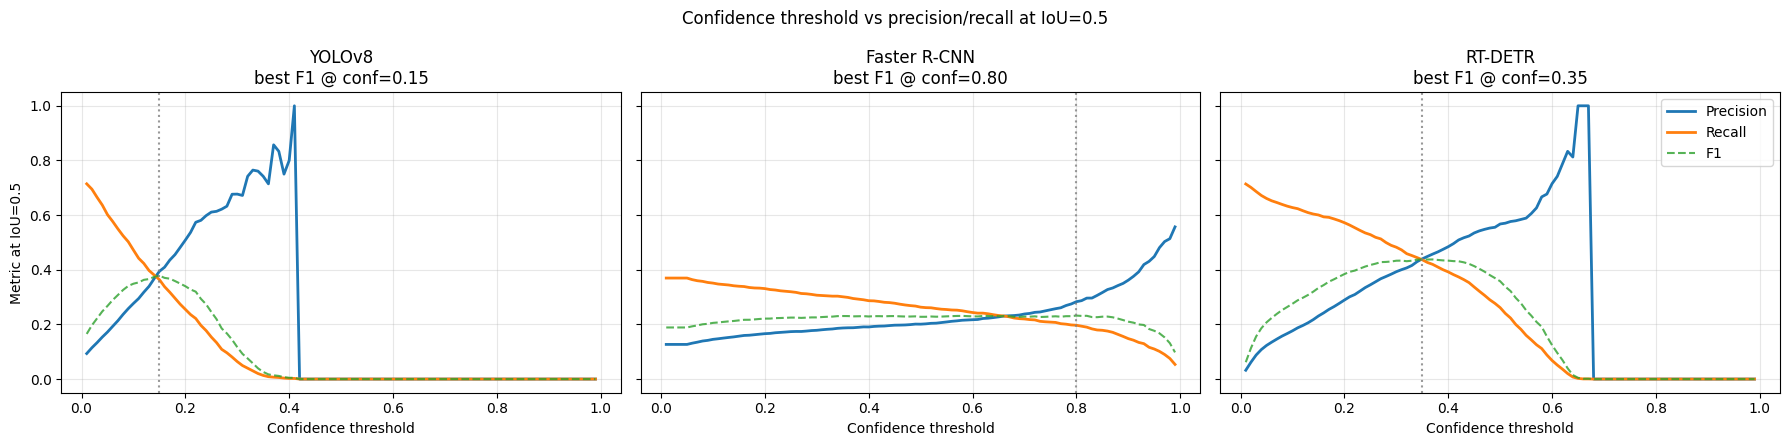

saved outputs/eval/confidence_precision_recall_iou05.png


In [11]:
# Confidence threshold vs precision/recall at IoU=0.5
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pycocotools.coco import COCO

from part1_detection.evaluate import _precision_recall_iou

# Ground truth and prediction JSONs produced by the unified evaluation cell above.
gt_json = Path(coco_root) / 'test' / '_annotations.coco.json'
coco_gt = COCO(str(gt_json))

pred_files = {
    'YOLOv8': Path('outputs/eval/yolo_test_detections.json'),
    'Faster R-CNN': Path('outputs/eval/frcnn_test_detections.json'),
    'RT-DETR': Path('outputs/eval/rtdetr_test_detections.json'),
}

missing = [str(p) for p in pred_files.values() if not p.exists()]
if missing:
    raise FileNotFoundError(
        'Missing detection JSONs. Run the unified evaluation cell first. Missing:\n'
        + '\n'.join(missing)
    )

thresholds = np.round(np.linspace(0.01, 0.99, 99), 2)
rows = []
for model_name, pred_path in pred_files.items():
    with open(pred_path) as f:
        detections = json.load(f)
    for thr in thresholds:
        m = _precision_recall_iou(
            coco_gt,
            detections,
            iou_thr=0.5,
            score_thr=float(thr),
        )
        precision = m['precision@0.5']
        recall = m['recall@0.5']
        f1 = 2 * precision * recall / (precision + recall + 1e-9)
        rows.append({
            'model': model_name,
            'confidence_threshold': float(thr),
            'precision@IoU0.5': precision,
            'recall@IoU0.5': recall,
            'f1@IoU0.5': f1,
            'TP': m['TP'],
            'FP': m['FP'],
            'FN': m['FN'],
        })

pr_df = pd.DataFrame(rows)
display(pr_df.groupby('model').apply(lambda d: d.loc[d['f1@IoU0.5'].idxmax()])[
    ['confidence_threshold', 'precision@IoU0.5', 'recall@IoU0.5', 'f1@IoU0.5', 'TP', 'FP', 'FN']
])

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
for ax, model_name in zip(axes, pred_files.keys()):
    d = pr_df[pr_df['model'] == model_name]
    ax.plot(d['confidence_threshold'], d['precision@IoU0.5'], label='Precision', linewidth=2)
    ax.plot(d['confidence_threshold'], d['recall@IoU0.5'], label='Recall', linewidth=2)
    ax.plot(d['confidence_threshold'], d['f1@IoU0.5'], label='F1', linestyle='--', alpha=0.8)
    best = d.loc[d['f1@IoU0.5'].idxmax()]
    ax.axvline(best['confidence_threshold'], color='gray', linestyle=':', alpha=0.8)
    ax.set_title(f"{model_name}\nbest F1 @ conf={best['confidence_threshold']:.2f}")
    ax.set_xlabel('Confidence threshold')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Metric at IoU=0.5')
axes[-1].legend(loc='best')
plt.suptitle('Confidence threshold vs precision/recall at IoU=0.5')
plt.tight_layout()
out_path = Path('outputs/eval/confidence_precision_recall_iou05.png')
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('saved', out_path)


## 6. Side-by-side bbox visualizations

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
saved outputs/viz/predictions_test.png


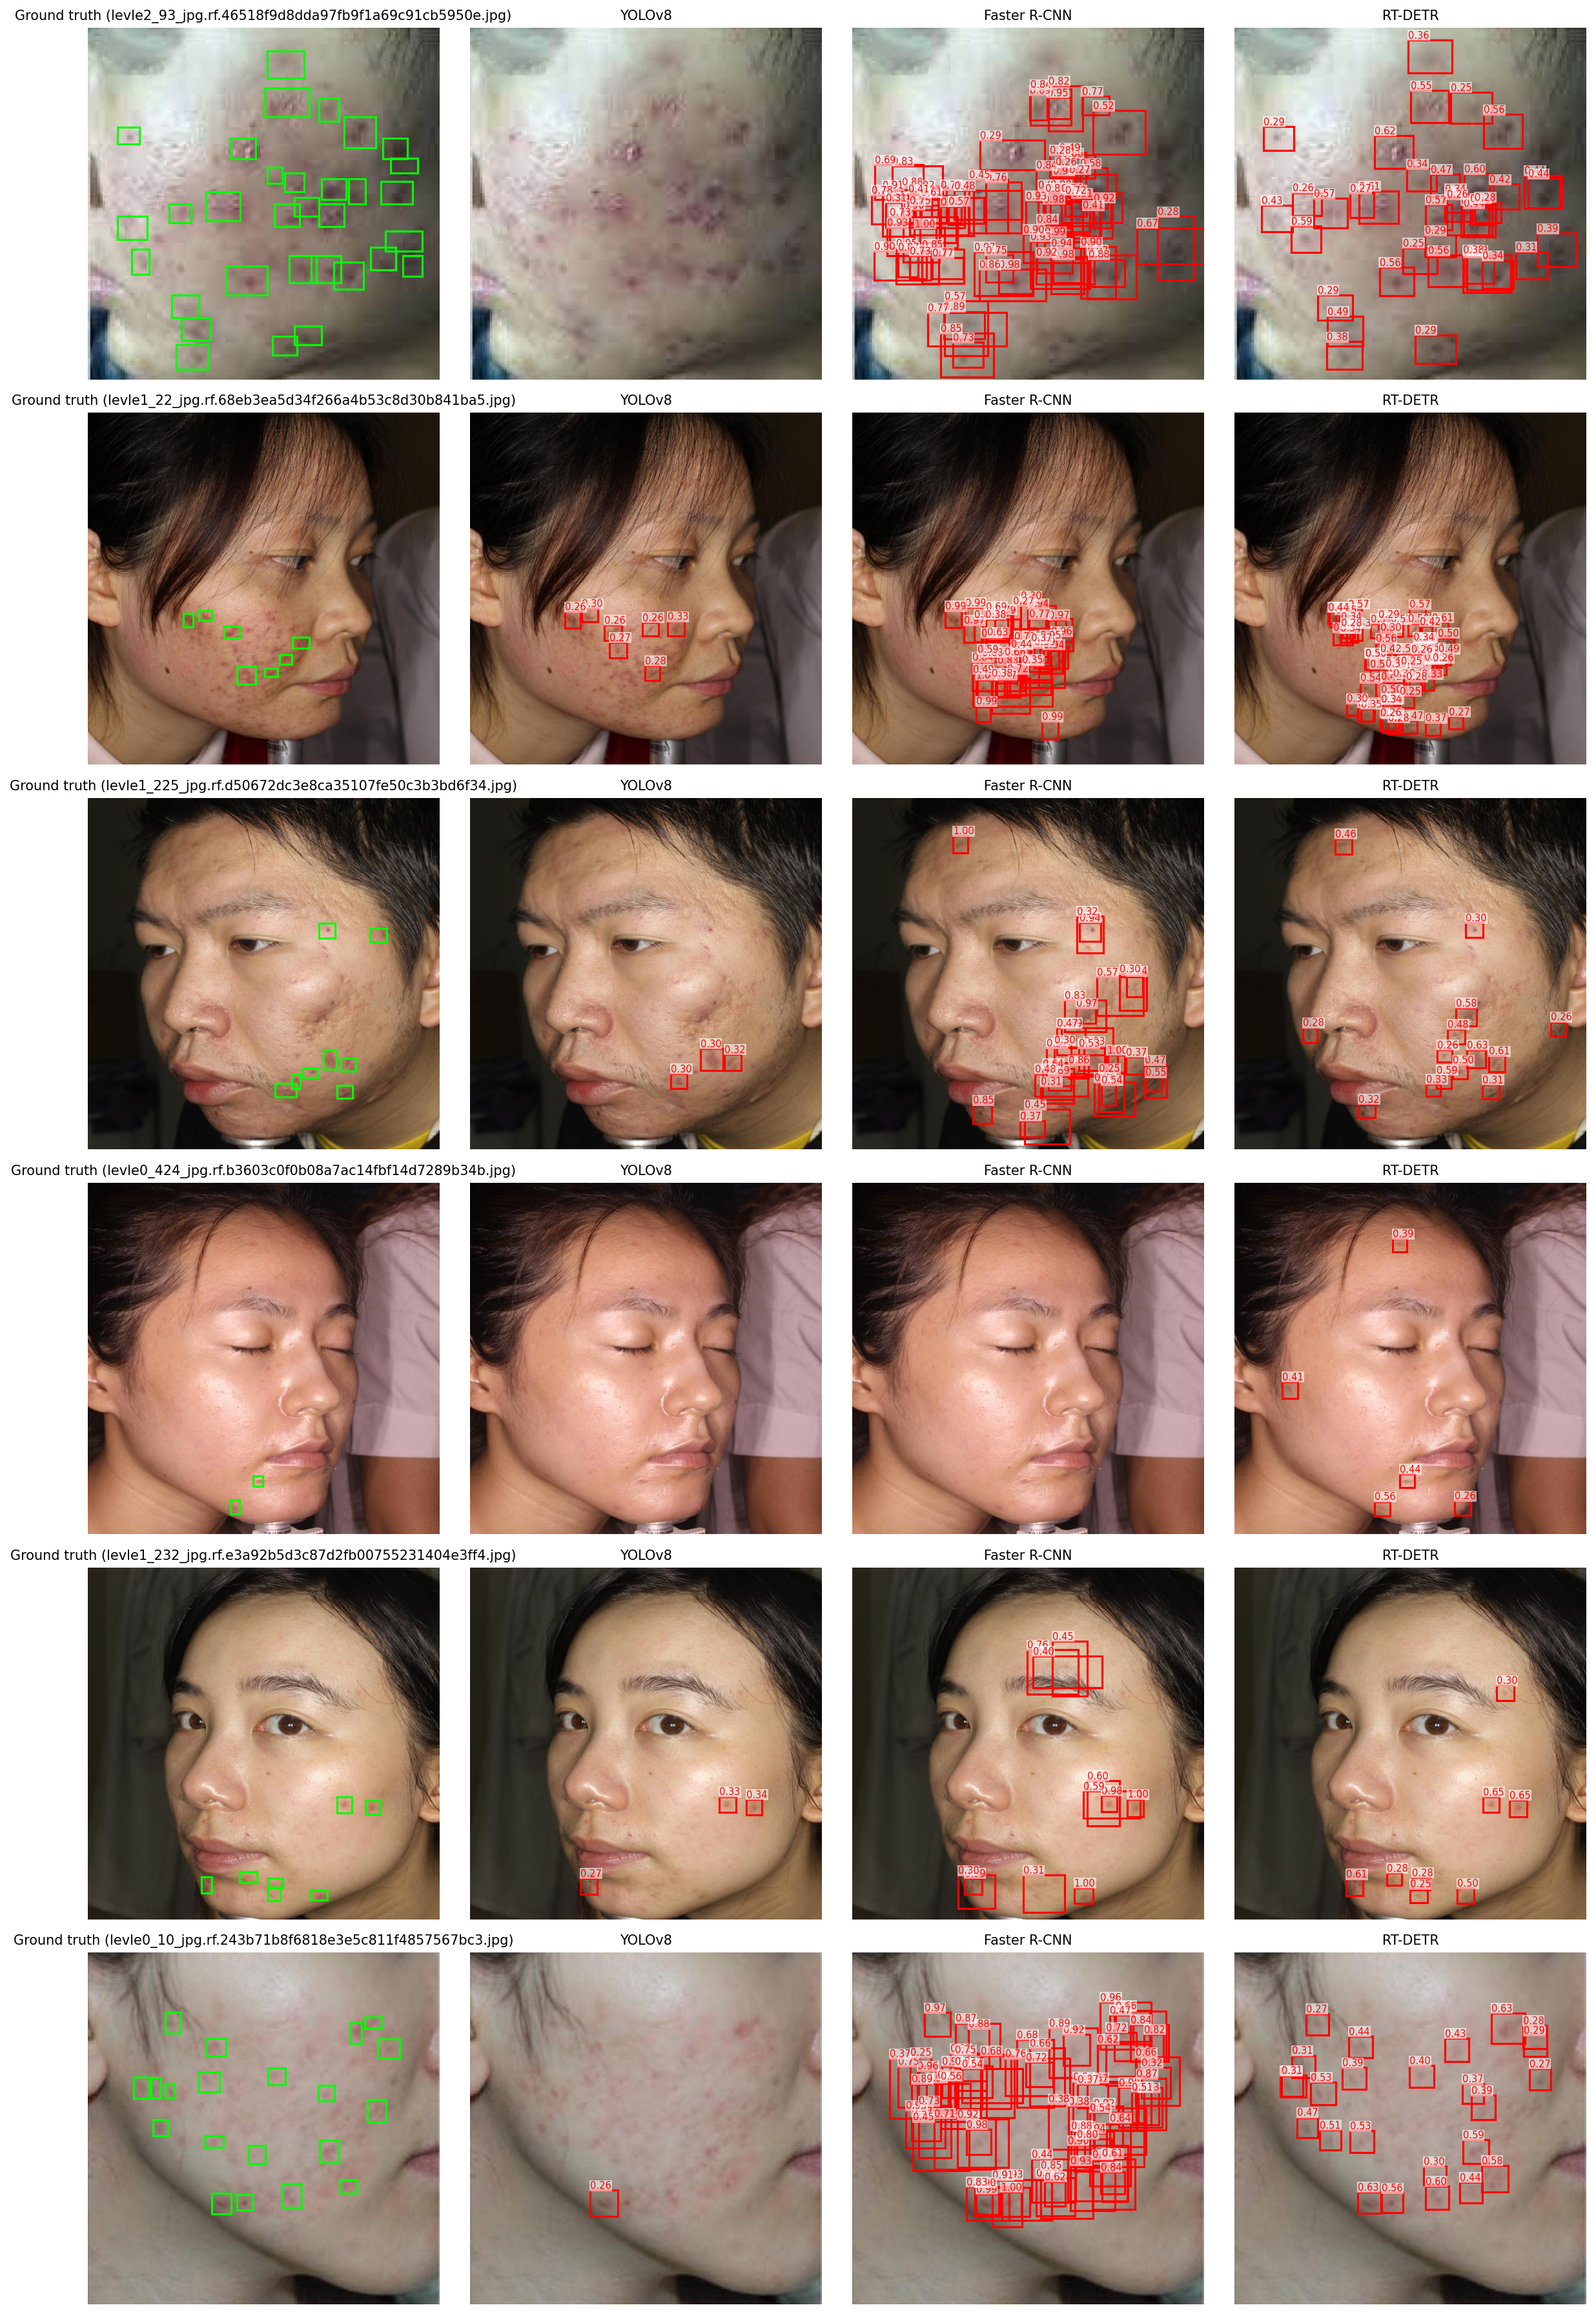

In [12]:
from part1_detection.visualize import visualize_predictions
from IPython.display import Image as IPyImage

out = visualize_predictions(
    models={
        'YOLOv8':       {'kind': 'yolo',   'weights': YOLO_WEIGHTS},
        'Faster R-CNN': {'kind': 'frcnn',  'weights': FRCNN_WEIGHTS},
        'RT-DETR':      {'kind': 'rtdetr', 'weights': RTDETR_WEIGHTS},
    },
    coco_root=str(coco_root),
    n_images=6,
)
IPyImage(filename=str(out))


In [13]:
# === Save all training artifacts to Google Drive ===
import os, shutil, datetime
DRIVE_ROOT = '/content/drive/MyDrive/acne_yang_project_runs'

# (optional) keep a timestamped snapshot so you don't overwrite earlier runs
SNAPSHOT = os.path.join(DRIVE_ROOT, datetime.datetime.now().strftime('snap_%Y%m%d_%H%M'))
os.makedirs(SNAPSHOT, exist_ok=True)

for src in ['outputs', 'runs']:
    if os.path.isdir(src):
        dst_latest   = os.path.join(DRIVE_ROOT, src)          # always-current copy
        dst_snapshot = os.path.join(SNAPSHOT,   src)          # frozen copy
        print(f'[save] {src}/ -> {dst_latest}/ (+ snapshot)')
        shutil.copytree(src, dst_latest,   dirs_exist_ok=True)
        shutil.copytree(src, dst_snapshot, dirs_exist_ok=True)
    else:
        print(f'[skip] {src}/ does not exist')

print('\n[save] done. Drive contents:')
!ls -lh "$DRIVE_ROOT"
print('\n[save] snapshot saved at:', SNAPSHOT)


[save] outputs/ -> /content/drive/MyDrive/acne_yang_project_runs/outputs/ (+ snapshot)
[save] runs/ -> /content/drive/MyDrive/acne_yang_project_runs/runs/ (+ snapshot)

[save] done. Drive contents:
total 32K
drwx------ 6 root root 4.0K May 24 03:26 outputs
drwx------ 3 root root 4.0K May 23 21:51 runs
drwx------ 4 root root 4.0K May 12 01:04 snap_20260512_0104
drwx------ 4 root root 4.0K May 12 09:28 snap_20260512_0928
drwx------ 4 root root 4.0K May 13 03:06 snap_20260513_0306
drwx------ 4 root root 4.0K May 14 02:20 snap_20260514_0220
drwx------ 4 root root 4.0K May 14 11:03 snap_20260514_1103
drwx------ 4 root root 4.0K May 24 03:27 snap_20260524_0326

[save] snapshot saved at: /content/drive/MyDrive/acne_yang_project_runs/snap_20260524_0326
